In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import logging

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [3]:
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [4]:
dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /Users/armandomaldonadosoberanis/tensorflow_datasets/mnist/incomplete.GAAPAQ_3.0.1/mnist-train.tfrec…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /Users/armandomaldonadosoberanis/tensorflow_datasets/mnist/incomplete.GAAPAQ_3.0.1/mnist-test.tfreco…

Dataset mnist downloaded and prepared to /Users/armandomaldonadosoberanis/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [5]:
class_names = ['Cero','Uno','Dos','Tres','Cuatro','Cinco','Seis','Siete','Ocho','Nueve']

In [6]:
num_train_examples = metadata.splits['train'].num_examples
num_test_examples = metadata.splits['test'].num_examples

In [7]:
def normalize(images, labels):
    images = tf.cast(images, tf.float32)
    images /= 255
    return images, labels

In [8]:
train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

/opt/homebrew/Caskroom/miniconda/base/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
BATCHSIZE = 32
train_dataset = train_dataset.repeat().shuffle(num_train_examples).batch(BATCHSIZE)
test_dataset = test_dataset.batch(BATCHSIZE)

In [12]:
model.fit(
    train_dataset,
    epochs=5,
    steps_per_epoch=math.ceil(num_train_examples/BATCHSIZE)
)

Epoch 1/5


I0000 00:00:1773102422.986039  201627 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 705us/step - accuracy: 0.9224 - loss: 0.2660
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 652us/step - accuracy: 0.9649 - loss: 0.1150
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 648us/step - accuracy: 0.9736 - loss: 0.0851
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 682us/step - accuracy: 0.9790 - loss: 0.0674
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 649us/step - accuracy: 0.9827 - loss: 0.0562


In [13]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    steps=math.ceil(num_test_examples/32)
)
print('Resultado en las pruebas:', test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 435us/step - accuracy: 0.9734 - loss: 0.0888
Resultado en las pruebas: 0.9733999967575073


In [14]:
for test_images, test_labels in test_dataset.take(1):
    test_images = test_images.numpy()
    test_labels = test_labels.numpy()
    predictions = model.predict(test_images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [15]:
def plot_image(i, predictions_array, true_labels, images):
    predictions_array, true_label, img = predictions_array[i], true_labels[i], images[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img[...,0], cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'
    plt.xlabel('Prediccion: {}'.format(class_names[predicted_label]), color=color)

In [16]:
def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array)
    plt.ylim([0,1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

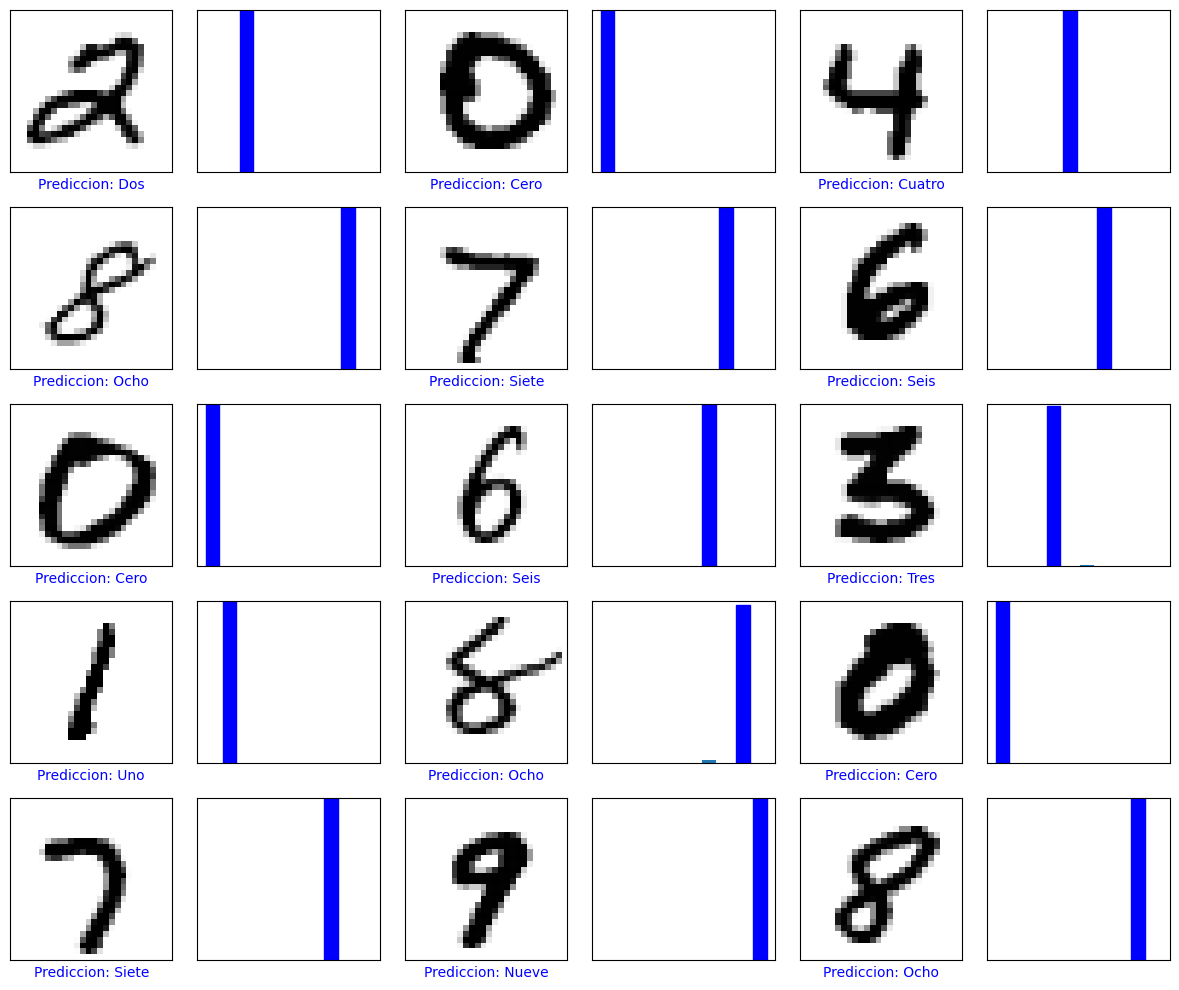

In [17]:
num_rows = 5
num_cols = 3
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_rows*num_cols):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions, test_labels, test_images)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions, test_labels)
plt.tight_layout()
plt.show()